# Juzgando por la portada 

Este notebook pretende mostrar la implementación y funcionamiento del proyecto *Juzgando por la portada* de la asignatura de Procesamiento de Imágenes Digitales (PID) de la Universidad de Sevilla. 

## Pasos previos
Si pretendes ejecutar este notebook, se recomienda encarecidamente usar CUDA para poder habilitar el entrenamiento con la GPU.
CUDA tiene que estar instalado de antemano.

TODO: actualizar 

> NOTA: se recomienda encarecidamente usar Linux directamente debido a las conocidas complicaciones de usar CUDA en Windows. Si aun así el usuario quisiera seguir usando Windows, se anima al usuario a encontrar soluciones y/o vías alternativas en foros o guías por su propia cuenta. 

# Imports

En esta celda puedes encontrar TODOS los imports que vas a necesitar a lo largo del notebook, asegúrate de que esta celda corre correctamente para evitar problemas futuros en la ejecución del notebook.

In [2]:
%load_ext autoreload
%autoreload 2

import os
import itertools
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from IPython.display import clear_output
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from lib  import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


I0000 00:00:1778163291.130635    2925 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778163294.062193    2925 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.



Verificando qué imágenes existen...
Total imágenes en CSV: 415966
Imágenes que existen: 404703
Imágenes faltantes: 11263

Datos después del filtrado:
Imágenes de entrenamiento: 323762
Imágenes de validación: 80941
Total usado para entrenar: 404703
Géneros (19): ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']
Resolución de entrada: (192, 288)

Creando datasets optimizados para GPU...


I0000 00:00:1778163534.428949    2925 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


OK: Datasets creados con map paralelo y prefetch


# Definición del modelo

Podemos observar que tenemos un modelo con 3 bloques, dos capas convolucionales con función de activación ReLU y MaxPooling, un tercer bloque con GAP y finalmente una última capa con función de activación sigmoide para tener una salida binaria multietiqueta. 

In [3]:
weight_decay = 1e-4

model = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.GlobalAveragePooling2D(),

    layers.Dense(512, activation='relu'),

    layers.Dense(len(genre_columns), activation='sigmoid', dtype='float32')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, weight_decay=weight_decay),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 192, 288, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 96, 144, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 144, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 72, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 72, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 36, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 19)             │         9,747 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 512,147 (1.95 MB)

 Trainable params: 512,147 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

# Busqueda en cuadrícula

Entrenando modelo con: 
 - Capas convolucionales: 3
 - Cantidad de filtros en la primera capa convolucional: 64
 - Capas densas: 1
 - Cantidad de neuronas en la primera capa densa: 512
Epoch 1/25


I0000 00:00:1778163537.898013    3966 service.cc:153] XLA service 0x792f300081c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778163537.898064    3966 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1778163537.954926    3966 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778163538.197395    3966 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1778163538.210995    3966 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2215__.38
I0000 00:00:1778163547.574825    3966 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1778164446.599367    3968 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2215__.38
E000

10118/10118 - 985s - 97ms/step - accuracy: 0.2984 - loss: 0.2446 - val_accuracy: 0.3333 - val_loss: 0.2372
Epoch 2/25


I0000 00:00:1778164522.263218    4056 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 704327026116028039
I0000 00:00:1778164522.263260    4056 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 18340927390720142208
/home/vegef/venvs/pid-train/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


10118/10118 - 65s - 6ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.3333 - val_loss: 0.2372
Epoch 3/25
10118/10118 - 956s - 94ms/step - accuracy: 0.3527 - loss: 0.2328 - val_accuracy: 0.3633 - val_loss: 0.2293
Epoch 4/25


...

10118/10118 - 63s - 6ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.4020 - val_loss: 0.2199
Epoch 11/25
10118/10118 - 948s - 94ms/step - accuracy: 0.4129 - loss: 0.2172 - val_accuracy: 0.4126 - val_loss: 0.2189
Epoch 12/25


I0000 00:00:1778169626.921336    4056 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 704327026116028039
I0000 00:00:1778169626.921395    4056 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 18340927390720142208


10118/10118 - 82s - 8ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.4126 - val_loss: 0.2189
Epoch 13/25
10118/10118 - 964s - 95ms/step - accuracy: 0.4198 - loss: 0.2151 - val_accuracy: 0.3914 - val_loss: 0.2199
Epoch 14/25


I0000 00:00:1778170672.547722    4056 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 704327026116028039
I0000 00:00:1778170672.547774    4056 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 18340927390720142208


10118/10118 - 63s - 6ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.3914 - val_loss: 0.2199
Entrenamiento completado
Epocas entrenadas: 14
Val loss final: 0.2199


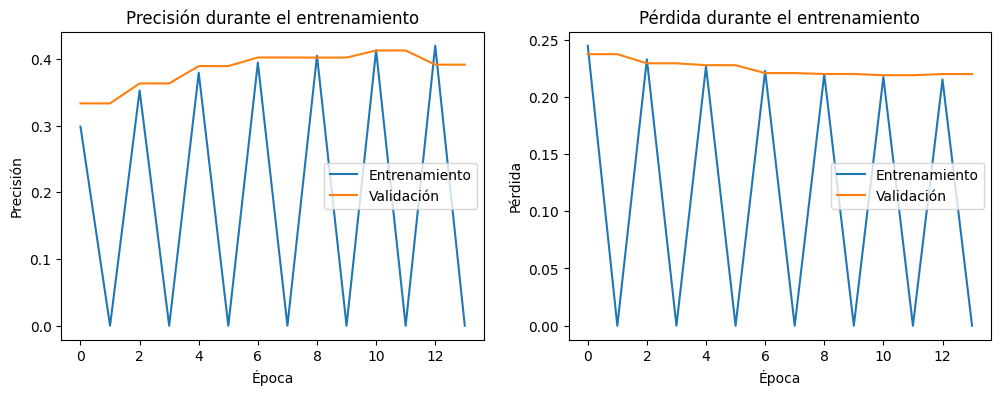

Etiquetas de validación usadas en evaluación: 80941
2530/2530 ━━━━━━━━━━━━━━━━━━━━ 68s 27ms/step

=== RESULTADOS DE EVALUACION ===
Exact Match Ratio: 0.1494
Precision (Micro): 0.6130
Recall (Micro): 0.1788
F1 Score (Micro): 0.2769
Precision (Macro): 0.5149
Recall (Macro): 0.0886
F1 Score (Macro): 0.1314


E0000 00:00:1778170841.537737    3967 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


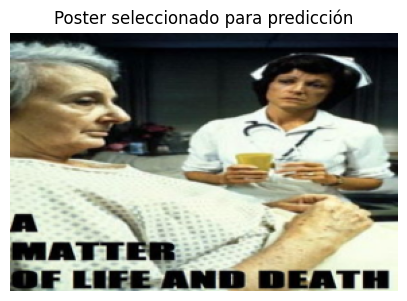

=== PREDICCION DEL MODELO ===
Imagen: ../imagenes/b2yuU7cHGFCKtLyITmhHjIXQZgK.jpg
Géneros reales: ['Drama', 'TV Movie']
Géneros predichos (umbral=0.5): ['Drama']

Top-5 probabilidades:
  - Drama: 0.5418
  - Crime: 0.1779
  - Thriller: 0.1568
  - Action: 0.1409
  - Documentary: 0.1284


In [4]:
RESULTS_DIR = "resultados_modelos"
os.makedirs(RESULTS_DIR, exist_ok=True)

path = os.path.join(RESULTS_DIR, f"conv3_filters64_dense1_neurons512_weight_decay")

def generate_text(metrics):
    text = """
WEIGHT DECAY

=== HIPERPARÁMETROS ===
  convLayers: 3
  firstConvFilterCount: 64
  denseLayers: 1
  firstDenseNeuronCount: 512

"""

    text += "\n=== MÉTRICAS ===\n"
    for k, v in metrics.items():
        text += f"  {k}: {v:.4f}\n"

    return text

print("Entrenando modelo con: ")
print(f" - Capas convolucionales: 3")
print(f" - Cantidad de filtros en la primera capa convolucional: 64")
print(f" - Capas densas: 1")
print(f" - Cantidad de neuronas en la primera capa densa: 512")

if os.path.exists(path):
    print(f"Saltando {os.path.basename(path)} (ya entrenado)")

history = train_model(model)
represent_data(history)
[exact_match, precision_micro, recall_micro, f1_micro, precision_macro, recall_macro, f1_macro] = evaluate_model(model)
predict_single_image(model)

save_result(path,
    generate_text(
    {
        "exact_match": exact_match,
        "precision_micro": precision_micro,
        "recall_micro": recall_micro,
        "f1_micro": f1_micro,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
    })
    ,model
)
    